# 文本分类任务

本实验演示如何将文本表示为张量，并用于分类任务。

我们将使用 **AG News** 数据集，对新闻标题进行四分类：World, Sports, Business, Sci/Tech。

In [1]:
# 设置代理
import os
os.environ['HTTP_PROXY'] = 'http://127.0.0.1:7890'
os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:7890'
print("代理已设置")

代理已设置


## 1. 环境准备与数据加载

In [2]:
import torch
import torchtext
import os
import collections
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
import tarfile

os.makedirs('./data', exist_ok=True)

# 直接从 CSV 加载原始文本数据（torchtext 返回 Tensor 而非原始文本）
data_dir = './data/ag_news_csv'
csv_file = os.path.join(data_dir, 'train.csv')

if not os.path.exists(csv_file):
    # 解压数据
    tar_file = './data/ag_news_csv.tar.gz'
    if os.path.exists(tar_file):
        with tarfile.open(tar_file, 'r:gz') as tar:
            tar.extractall('./data')

if os.path.exists(csv_file):
    train_df = pd.read_csv(csv_file, header=None, names=['label', 'title', 'description'])
    test_df = pd.read_csv(os.path.join(data_dir, 'test.csv'), header=None, names=['label', 'title', 'description'])
    
    # 合并标题和描述作为完整文本
    train_dataset = [(row['label'], row['title'] + ' ' + row['description']) for _, row in train_df.iterrows()]
    test_dataset = [(row['label'], row['title'] + ' ' + row['description']) for _, row in test_df.iterrows()]
    print("从 CSV 文件加载成功")
else:
    # 回退方案
    from torchtext.datasets import AG_NEWS
    train_dataset = list(AG_NEWS(root='./data', split='train'))
    test_dataset = list(AG_NEWS(root='./data', split='test'))
    print("从 torchtext 加载")

classes = ['World', 'Sports', 'Business', 'Sci/Tech']

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"类别: {classes}")

从 CSV 文件加载成功
训练集大小: 120000
测试集大小: 7600
类别: ['World', 'Sports', 'Business', 'Sci/Tech']


### 查看数据样本

In [3]:
for i, (label, text) in enumerate(train_dataset[:5]):
    print(f"**{classes[label-1]}** -> {text[:100]}...")
    print()

**Business** -> Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...

**Business** -> Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...

**Business** -> Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about th...

**Business** -> Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil e...

**Business** -> Oil prices soar to all-time record, posing new menace to US economy (AFP) AFP - Tearaway world oil p...



## 2. 文本分词与词汇表构建

### 分词 (Tokenization)

将文本分割成独立的 token（词）。

In [4]:
# 使用 basic_english 分词器
tokenizer = torchtext.data.utils.get_tokenizer('basic_english')

# 示例
sample_text = "Hello! This is a test sentence."
tokens = tokenizer(sample_text)
print(f"原文: {sample_text}")
print(f"分词结果: {tokens}")

原文: Hello! This is a test sentence.
分词结果: ['hello', '!', 'this', 'is', 'a', 'test', 'sentence', '.']


### 构建词汇表 (Vocabulary)

In [5]:
# 统计所有词的频率
counter = collections.Counter()
for (label, line) in train_dataset:
    counter.update(tokenizer(line))

# 构建词汇表 (torchtext 0.6.0 使用 Vocab 类)
vocab = torchtext.vocab.Vocab(counter, min_freq=1)
vocab_size = len(vocab)

print(f"词汇表大小: {vocab_size}")
print(f"\n最常见的 10 个词:")
for word, count in counter.most_common(10):
    print(f"  {word}: {count}")

词汇表大小: 95812

最常见的 10 个词:
  .: 225971
  the: 203843
  ,: 165685
  to: 119205
  a: 110153
  of: 97909
  in: 95488
  and: 68872
  s: 61724
  on: 56529


In [6]:
# 词到索引的映射 (torchtext 0.6.0 使用 .stoi 属性)
stoi = vocab.stoi

def encode(text):
    """将文本转换为索引序列"""
    return [stoi.get(s, 0) for s in tokenizer(text)]

# 示例
sample = "I love natural language processing"
print(f"文本: {sample}")
print(f"编码: {encode(sample)}")

文本: I love natural language processing
编码: [283, 2321, 2255, 3224, 3831]


## 3. 词袋模型 (Bag of Words)

将文本表示为词频向量，每个维度对应词汇表中的一个词。

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# 简单示例
corpus = [
    'I like hot dogs.',
    'The dog ran fast.',
    'Its hot outside.',
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

print("词汇表:", vectorizer.vocabulary_)
print("\nBoW 矩阵:")
print(X.toarray())

词汇表: {'like': 5, 'hot': 3, 'dogs': 1, 'the': 8, 'dog': 0, 'ran': 7, 'fast': 2, 'its': 4, 'outside': 6}

BoW 矩阵:
[[0 1 0 1 0 1 0 0 0]
 [1 0 1 0 0 0 0 1 1]
 [0 0 0 1 1 0 1 0 0]]


In [8]:
def to_bow(text, bow_vocab_size=vocab_size):
    """将文本转换为词袋向量"""
    res = torch.zeros(bow_vocab_size, dtype=torch.float32)
    for i in encode(text):
        if i < bow_vocab_size:
            res[i] += 1
    return res

# 示例 (train_dataset[0][1] 现在是字符串)
sample_text = train_dataset[0][1]
bow_vector = to_bow(sample_text)
print(f"文本: {sample_text[:80]}...")
print(f"BoW 向量维度: {bow_vector.shape}")
print(f"非零元素数量: {(bow_vector > 0).sum().item()}")

文本: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall ...
BoW 向量维度: torch.Size([95812])
非零元素数量: 25


## 4. N-grams 表示

考虑词的顺序，将连续的 N 个词作为一个单元。

In [9]:
# Bigram 示例
bigram_vectorizer = CountVectorizer(ngram_range=(1, 2), token_pattern=r'\b\w+\b', min_df=1)
bigram_vectorizer.fit_transform(corpus)

print("Bigram 词汇表 (部分):")
vocab_items = list(bigram_vectorizer.vocabulary_.items())[:15]
for word, idx in vocab_items:
    print(f"  {word}: {idx}")

Bigram 词汇表 (部分):
  i: 7
  like: 11
  hot: 4
  dogs: 2
  i like: 8
  like hot: 12
  hot dogs: 5
  the: 16
  dog: 0
  ran: 14
  fast: 3
  the dog: 17
  dog ran: 1
  ran fast: 15
  its: 9


In [10]:
# 构建 bigram 词汇表
counter_ngram = collections.Counter()
for (label, line) in train_dataset:
    l = tokenizer(line)
    counter_ngram.update(torchtext.data.utils.ngrams_iterator(l, ngrams=2))

# torchtext 0.6.0 使用 Vocab 类
bi_vocab = torchtext.vocab.Vocab(counter_ngram, min_freq=2)  # 过滤低频 bigram
print(f"Bigram 词汇表大小: {len(bi_vocab)}")

Bigram 词汇表大小: 481971


## 5. TF-IDF 表示

TF-IDF 降低常见词的权重，突出重要词。

$$w_{ij} = tf_{ij} \times \log(N/df_i)$$

- $tf_{ij}$: 词 i 在文档 j 中的出现次数
- $N$: 文档总数
- $df_i$: 包含词 i 的文档数

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 示例
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
tfidf_vectorizer.fit_transform(corpus)

test_sentence = 'My dog likes hot dogs on a hot day.'
tfidf_vec = tfidf_vectorizer.transform([test_sentence])

print(f"测试句子: {test_sentence}")
print(f"TF-IDF 向量: {tfidf_vec.toarray()}")

测试句子: My dog likes hot dogs on a hot day.
TF-IDF 向量: [[0.43381609 0.         0.43381609 0.         0.65985664 0.43381609
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]]


## 6. 训练文本分类器

In [12]:
from torch.utils.data import DataLoader

def bowify(batch):
    """将批次数据转换为 BoW 表示"""
    return (
        torch.LongTensor([t[0]-1 for t in batch]),
        torch.stack([to_bow(t[1]) for t in batch])
    )

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=bowify, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=bowify, shuffle=False)

print("DataLoader 创建完成")

DataLoader 创建完成


In [13]:
# 定义简单的线性分类器
class BoWClassifier(torch.nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()
        self.fc = torch.nn.Linear(vocab_size, num_classes)
        self.log_softmax = torch.nn.LogSoftmax(dim=1)
    
    def forward(self, x):
        return self.log_softmax(self.fc(x))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = BoWClassifier(vocab_size, 4).to(device)

print(f"模型参数量: {sum(p.numel() for p in model.parameters())}")
print(f"设备: {device}")

模型参数量: 383252
设备: cuda


In [14]:
def train_epoch(model, dataloader, optimizer, loss_fn, device, epoch_size=None, report_freq=200):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for i, (labels, features) in enumerate(dataloader):
        labels, features = labels.to(device), features.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
        if (i + 1) % report_freq == 0:
            print(f"  Step {total}: Loss={total_loss/total:.4f}, Acc={correct/total:.4f}")
        
        if epoch_size and total >= epoch_size:
            break
    
    return total_loss / total, correct / total

def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for labels, features in dataloader:
            labels, features = labels.to(device), features.to(device)
            outputs = model(features)
            loss = loss_fn(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / total, correct / total

In [15]:
# 训练
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.NLLLoss()

num_epochs = 3
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("开始训练...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_fn, device, epoch_size=30000)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

开始训练...

Epoch 1/3
  Step 3200: Loss=0.0362, Acc=0.8213
  Step 6400: Loss=0.0300, Acc=0.8458
  Step 9600: Loss=0.0274, Acc=0.8580
  Step 12800: Loss=0.0259, Acc=0.8647
  Step 16000: Loss=0.0251, Acc=0.8701
  Step 19200: Loss=0.0243, Acc=0.8743
  Step 22400: Loss=0.0239, Acc=0.8775
  Step 25600: Loss=0.0234, Acc=0.8797
  Step 28800: Loss=0.0235, Acc=0.8809
Train Loss: 0.0235, Train Acc: 0.8810
Test Loss: 0.0233, Test Acc: 0.8926

Epoch 2/3
  Step 3200: Loss=0.0172, Acc=0.9172
  Step 6400: Loss=0.0187, Acc=0.9156
  Step 9600: Loss=0.0185, Acc=0.9170
  Step 12800: Loss=0.0191, Acc=0.9125
  Step 16000: Loss=0.0191, Acc=0.9118
  Step 19200: Loss=0.0195, Acc=0.9103
  Step 22400: Loss=0.0193, Acc=0.9099
  Step 25600: Loss=0.0194, Acc=0.9092
  Step 28800: Loss=0.0198, Acc=0.9077
Train Loss: 0.0197, Train Acc: 0.9078
Test Loss: 0.0250, Test Acc: 0.8993

Epoch 3/3
  Step 3200: Loss=0.0167, Acc=0.9275
  Step 6400: Loss=0.0165, Acc=0.9284
  Step 9600: Loss=0.0164, Acc=0.9273
  Step 12800: Loss=0.0

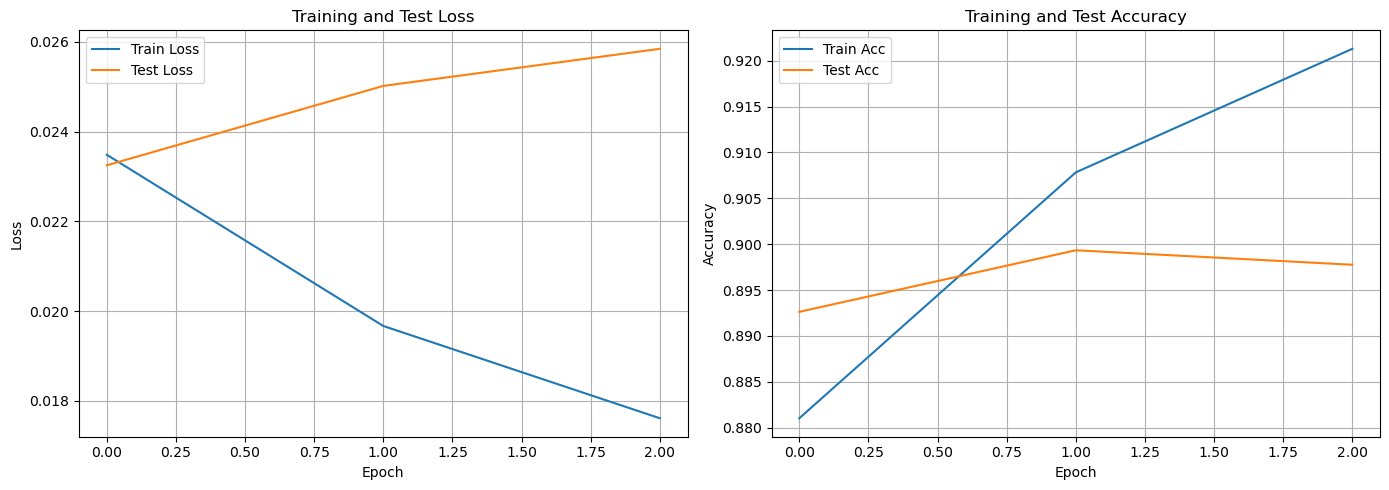

In [16]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(test_accs, label='Test Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. 预测示例

In [17]:
def predict(text, model, vocab_size):
    """预测文本类别"""
    model.eval()
    bow = to_bow(text, vocab_size).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(bow)
        pred = torch.argmax(output, dim=1).item()
    return classes[pred]

# 测试样本
test_samples = [
    "The president announced new trade policies with foreign countries.",
    "The team won the championship game in overtime.",
    "Stock prices rose significantly after the earnings report.",
    "Scientists discovered a new species of dinosaur in Argentina."
]

print("预测结果:")
print("="*60)
for text in test_samples:
    pred = predict(text, model, vocab_size)
    print(f"文本: {text[:50]}...")
    print(f"预测类别: {pred}")
    print("-"*60)

预测结果:
文本: The president announced new trade policies with fo...
预测类别: World
------------------------------------------------------------
文本: The team won the championship game in overtime....
预测类别: Sports
------------------------------------------------------------
文本: Stock prices rose significantly after the earnings...
预测类别: Business
------------------------------------------------------------
文本: Scientists discovered a new species of dinosaur in...
预测类别: Sci/Tech
------------------------------------------------------------


## 8. 方法对比

In [18]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# 准备数据
train_texts = [t[1] for t in train_dataset[:5000]]
train_labels = [t[0]-1 for t in train_dataset[:5000]]
test_texts = [t[1] for t in test_dataset[:1000]]
test_labels = [t[0]-1 for t in test_dataset[:1000]]

results = []

# 方法1: BoW
print("训练 BoW 模型...")
start = time.time()
bow_vec = CountVectorizer(max_features=10000)
X_train_bow = bow_vec.fit_transform(train_texts)
X_test_bow = bow_vec.transform(test_texts)
clf_bow = LogisticRegression(max_iter=100)
clf_bow.fit(X_train_bow, train_labels)
bow_acc = accuracy_score(test_labels, clf_bow.predict(X_test_bow))
bow_time = time.time() - start
results.append(('BoW', bow_acc, bow_time, X_train_bow.shape[1]))

# 方法2: TF-IDF
print("训练 TF-IDF 模型...")
start = time.time()
tfidf_vec = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vec.fit_transform(train_texts)
X_test_tfidf = tfidf_vec.transform(test_texts)
clf_tfidf = LogisticRegression(max_iter=100)
clf_tfidf.fit(X_train_tfidf, train_labels)
tfidf_acc = accuracy_score(test_labels, clf_tfidf.predict(X_test_tfidf))
tfidf_time = time.time() - start
results.append(('TF-IDF', tfidf_acc, tfidf_time, X_train_tfidf.shape[1]))

# 方法3: Bigram BoW
print("训练 Bigram BoW 模型...")
start = time.time()
bigram_vec = CountVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_bigram = bigram_vec.fit_transform(train_texts)
X_test_bigram = bigram_vec.transform(test_texts)
clf_bigram = LogisticRegression(max_iter=100)
clf_bigram.fit(X_train_bigram, train_labels)
bigram_acc = accuracy_score(test_labels, clf_bigram.predict(X_test_bigram))
bigram_time = time.time() - start
results.append(('Bigram BoW', bigram_acc, bigram_time, X_train_bigram.shape[1]))

训练 BoW 模型...
训练 TF-IDF 模型...
训练 Bigram BoW 模型...


In [19]:
# 显示对比结果
print("\n" + "="*70)
print("方法对比结果")
print("="*70)
print(f"{'方法':<15} {'准确率':<12} {'训练时间(s)':<15} {'特征维度':<12}")
print("-"*70)
for name, acc, t, dim in results:
    print(f"{name:<15} {acc:<12.4f} {t:<15.2f} {dim:<12}")
print("="*70)


方法对比结果
方法              准确率          训练时间(s)         特征维度        
----------------------------------------------------------------------
BoW             0.8250       0.58            10000       
TF-IDF          0.8560       0.41            10000       
Bigram BoW      0.8300       0.97            10000       


## 总结

### 本实验学习了：
1. **分词 (Tokenization)**: 将文本分割成 token
2. **词汇表 (Vocabulary)**: 构建词到索引的映射
3. **词袋模型 (BoW)**: 将文本表示为词频向量
4. **N-grams**: 捕获词序信息
5. **TF-IDF**: 降低常见词权重

### 局限性：
- BoW 和 TF-IDF 无法捕获语义和词序
- 需要更强大的模型（如 Word2Vec、BERT）来捕获上下文信息